# March Machine Learning Mania 2026

Predict NCAA tournament outcomes (men's + women's) using an ensemble of XGBoost, LightGBM, AdaBoost, and TabICL v2.

TabFPN v2 was tried at first, but TabICL v2 was kept because it performs better.

- **Metric**: Brier score (MSE for binary outcomes)
- **Target**: P(lower TeamID beats higher TeamID)

## 1. Setup

In [1]:
import sys
sys.path.append("/kaggle/usr/lib/notebooks/aelhajj/utils_py")
sys.path.append("/kaggle/usr/lib/notebooks/aelhajj/theme_py")

In [2]:
%pip install catppuccin[matplotlib] --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install tabicl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 5.6 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from theme_py import apply
from utils_py import (
    load_data, compute_elo, compute_elo_trajectory_stats, compute_season_stats, compute_massey_features,
    build_seed_map, build_training_data, build_features_vectorized, parse_seed,
    train_or_load, brier_score, leave_one_season_out_cv, leave_one_season_out_cv_gendered,
    compute_sample_weights,
    generate_submission, generate_submission_gendered,
    compute_sos, compute_momentum, compute_conference_strength, compute_coach_experience,
    plot_brier_by_season, plot_feature_importance,
    plot_prediction_distribution, plot_calibration_curve,
    plot_model_comparison,
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tabicl import TabICLClassifier

warnings.filterwarnings("ignore")
C = apply("mocha")
RANDOM_STATE = 42

## 2. Data Loading

In [6]:
data = load_data(Path("/kaggle/input/competitions/march-machine-learning-mania-2026"))
#data = load_data()
for name, df in data.items():
    print(f"{name:25s} {str(df.shape):>15s}")

m_teams                          (381, 4)
w_teams                          (379, 2)
m_regular                     (196823, 8)
w_regular                     (140825, 8)
m_regular_detail             (122775, 34)
w_regular_detail              (85505, 34)
m_tourney                       (2585, 8)
w_tourney                       (1717, 8)
m_tourney_detail               (1449, 34)
w_tourney_detail                (961, 34)
m_seeds                         (2626, 3)
w_seeds                         (1744, 3)
m_massey                     (5761702, 5)
m_conferences                  (13753, 3)
w_conferences                   (9853, 3)
m_coaches                      (13898, 5)
sample_sub                    (519144, 2)
sample_sub2                   (132133, 2)


In [7]:
data["m_regular_detail"].head(3)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23


In [8]:
# Submission structure
print("Stage 1:", data["sample_sub"].shape)
print(data["sample_sub"].head())
print()
print("Stage 2:", data["sample_sub2"].shape)
print(data["sample_sub2"].head())

Stage 1: (519144, 2)
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5

Stage 2: (132133, 2)
               ID  Pred
0  2026_1101_1102   0.5
1  2026_1101_1103   0.5
2  2026_1101_1104   0.5
3  2026_1101_1105   0.5
4  2026_1101_1106   0.5


## 3. EDA

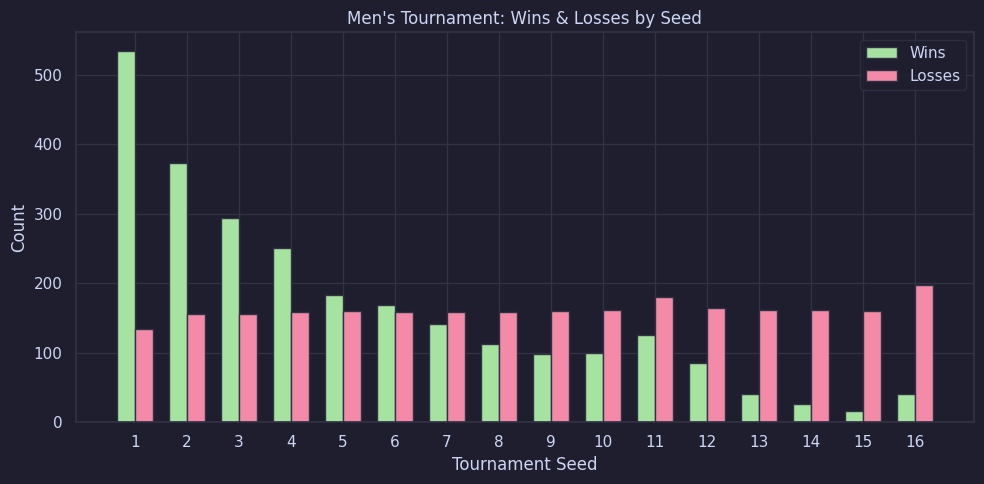

In [9]:
# Seed vs tournament wins (men's)
m_seeds = data["m_seeds"].copy()
m_seeds["SeedNum"] = m_seeds["Seed"].apply(parse_seed)
m_tourney = data["m_tourney"]

# Count wins by seed
w_seeds = m_tourney.merge(m_seeds, left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
seed_wins = w_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

l_seeds = m_tourney.merge(m_seeds, left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
seed_losses = l_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 17)
w = 0.35
ax.bar(x - w/2, seed_wins.values, w, label="Wins", color=C.green)
ax.bar(x + w/2, seed_losses.values, w, label="Losses", color=C.red)
ax.set_xlabel("Tournament Seed")
ax.set_ylabel("Count")
ax.set_title("Men's Tournament: Wins & Losses by Seed")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

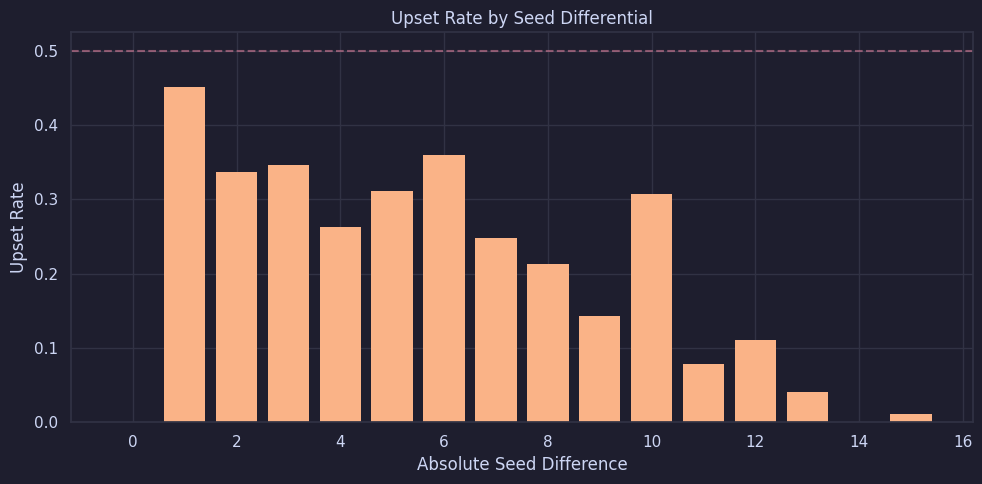

In [10]:
# Upset frequency: how often does the higher seed (worse number) win?
tourney_all = pd.concat([data["m_tourney"], data["w_tourney"]], ignore_index=True)
all_seeds = pd.concat([data["m_seeds"], data["w_seeds"]], ignore_index=True)
all_seeds["SeedNum"] = all_seeds["Seed"].apply(parse_seed)
seed_lookup = dict(zip(zip(all_seeds["Season"], all_seeds["TeamID"]), all_seeds["SeedNum"]))

upsets = []
for _, row in tourney_all.iterrows():
    ws = seed_lookup.get((row["Season"], row["WTeamID"]))
    ls = seed_lookup.get((row["Season"], row["LTeamID"]))
    if ws is not None and ls is not None:
        diff = abs(ws - ls)
        upset = ws > ls  # winner had a worse (higher) seed number
        upsets.append({"SeedDiff": diff, "Upset": int(upset)})

upset_df = pd.DataFrame(upsets)
upset_rate = upset_df.groupby("SeedDiff")["Upset"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(upset_rate.index, upset_rate.values, color=C.peach, edgecolor="none")
ax.axhline(0.5, color=C.red, linestyle="--", alpha=0.5)
ax.set_xlabel("Absolute Seed Difference")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate by Seed Differential")
plt.tight_layout()
plt.show()

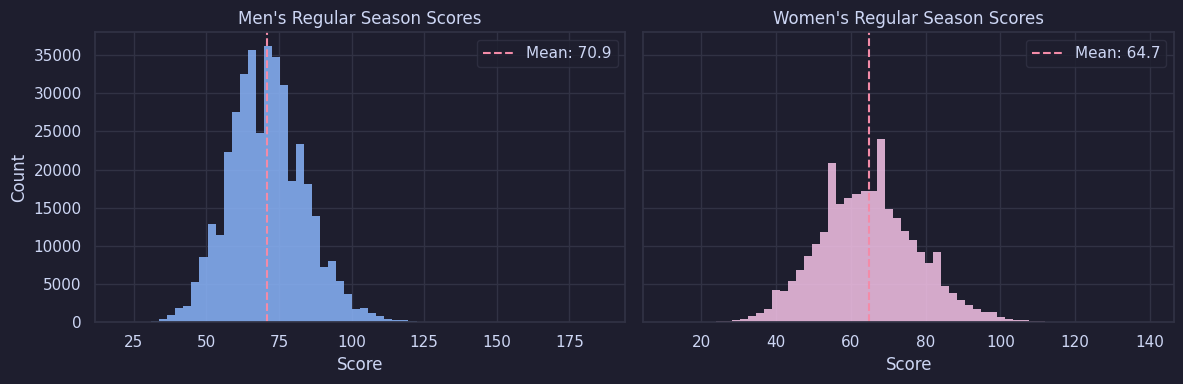

In [11]:
# Score distributions (men's vs women's regular season)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (key, title, color) in zip(axes, [
    ("m_regular", "Men's", C.blue),
    ("w_regular", "Women's", C.pink),
]):
    df = data[key]
    scores = pd.concat([df["WScore"], df["LScore"]])
    ax.hist(scores, bins=60, color=color, edgecolor="none", alpha=0.85)
    ax.set_xlabel("Score")
    ax.set_title(f"{title} Regular Season Scores")
    ax.axvline(scores.mean(), color=C.red, linestyle="--", label=f"Mean: {scores.mean():.1f}")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

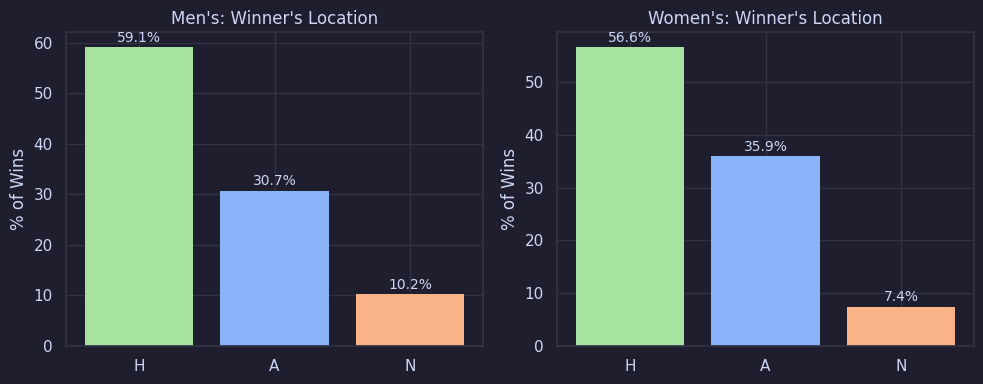

In [12]:
# Home court advantage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (key, title) in zip(axes, [("m_regular", "Men's"), ("w_regular", "Women's")]):
    df = data[key]
    loc_counts = df["WLoc"].value_counts()
    total_games = len(df)
    pcts = (loc_counts / total_games * 100)
    bars = ax.bar(pcts.index, pcts.values, color=[C.green, C.blue, C.peach][:len(pcts)], edgecolor="none")
    ax.set_ylabel("% of Wins")
    ax.set_title(f"{title}: Winner's Location")
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

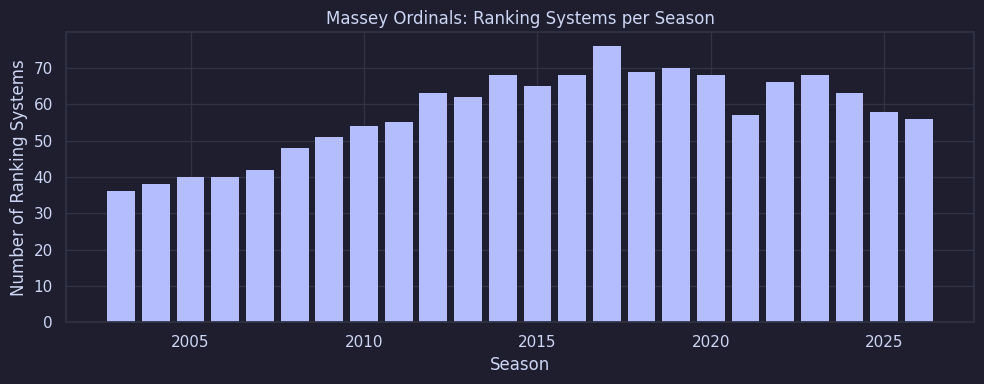

In [13]:
# Massey ordinals: systems per season
massey = data["m_massey"]
systems_per_season = massey.groupby("Season")["SystemName"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(systems_per_season.index, systems_per_season.values, color=C.lavender, edgecolor="none")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Ranking Systems")
ax.set_title("Massey Ordinals: Ranking Systems per Season")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [14]:
# Elo: previous season (end-of-season, includes tournament) -- long-term baseline
m_elo_prev = compute_elo(data["m_regular"], data["m_tourney"], include_tourney=True)
w_elo_prev = compute_elo(data["w_regular"], data["w_tourney"], include_tourney=True)
elo_prev = {**m_elo_prev, **w_elo_prev}
print(f"Previous-season Elo: {len(elo_prev):,} ratings")

Previous-season Elo: 24,158 ratings


In [15]:
# Elo: current season with margin-of-victory scaling (MOV-Elo)
# MOV-Elo scales K by log(margin+1) with autocorrelation correction -- a 30-pt blowout
# gives a bigger Elo update than a 1-pt squeaker. Proven in FiveThirtyEight's NBA model.
m_elo_curr = compute_elo(data["m_regular"], include_tourney=False, mov=True)
w_elo_curr = compute_elo(data["w_regular"], include_tourney=False, mov=True)
elo_curr = {**m_elo_curr, **w_elo_curr}
print(f"Current-season MOV-Elo: {len(elo_curr):,} ratings")

Current-season MOV-Elo: 24,158 ratings


In [16]:
# Seeds, season stats, Massey
seed_map  = build_seed_map(data["m_seeds"], data["w_seeds"])
print(f"Seed map: {len(seed_map):,} entries")

m_stats = compute_season_stats(data["m_regular_detail"])
w_stats = compute_season_stats(data["w_regular_detail"])
stats_df = pd.concat([m_stats, w_stats], ignore_index=True)
print(f"Season stats: {len(stats_df):,} team-seasons")

massey_df = compute_massey_features(data["m_massey"], day_threshold=128)
print(f"Massey features: {len(massey_df):,} team-seasons")

Seed map: 4,370 entries
Season stats: 14,311 team-seasons
Massey features: 7,980 team-seasons


In [17]:
# Sanity check: top men's teams by end-of-2025 Elo
m_teams_lut = dict(zip(data["m_teams"]["TeamID"], data["m_teams"]["TeamName"]))
top_m = sorted(
    [(m_teams_lut.get(tid, tid), r) for (s, tid), r in elo_prev.items()
     if s == 2025 and tid < 2000],
    key=lambda x: -x[1]
)[:10]
print("Top 10 men's teams by end-of-2025 Elo:")
for i, (name, elo) in enumerate(top_m, 1):
    print(f"  {i:2d}. {name}: {elo:.0f}")

Top 10 men's teams by end-of-2025 Elo:
   1. Houston: 1862
   2. Florida: 1820
   3. Duke: 1816
   4. Auburn: 1792
   5. Alabama: 1767
   6. Tennessee: 1765
   7. Drake: 1752
   8. Connecticut: 1744
   9. Michigan St: 1740
  10. St Mary's CA: 1738


In [18]:
# Elo trajectory stats: within-season trend and volatility per (Season, TeamID)
# Using MOV-Elo so trajectory captures margin-of-victory signal
m_elo_stats = compute_elo_trajectory_stats(data['m_regular'], mov=True)
w_elo_stats = compute_elo_trajectory_stats(data['w_regular'], mov=True)
elo_stats = {**m_elo_stats, **w_elo_stats}
print(f'Elo trajectory stats: {len(elo_stats):,} entries')
sample_key = next(iter(elo_stats))
print(f'Sample {sample_key}: {elo_stats[sample_key]}')

Elo trajectory stats: 23,604 entries
Sample (1985, 1228): {'EloTrend': 6.185524298654294, 'EloStd': 60.62869459854287}


In [19]:
# Strength of Schedule: mean Elo of each team's opponents
sos = compute_sos(data["m_regular"], data["w_regular"], elo_curr)
print(f"SOS: {len(sos):,} entries")

# Last-10-game momentum: win rate in final 10 regular-season games
momentum = compute_momentum(data["m_regular"], data["w_regular"], last_n=10)
print(f"Momentum: {len(momentum):,} entries")

# Conference strength: mean Elo of all teams in a team's conference
conf_strength = compute_conference_strength(data["m_conferences"], data["w_conferences"], elo_curr)
print(f"Conference strength: {len(conf_strength):,} entries")

# Coach tournament experience: cumulative NCAA tournament appearances (men only)
coach_exp = compute_coach_experience(data["m_coaches"], data["m_tourney"])
print(f"Coach experience: {len(coach_exp):,} entries (men only)")

SOS: 23,604 entries
Momentum: 23,604 entries
Conference strength: 23,606 entries
Coach experience: 13,398 entries (men only)


## 5. Training Data

In [ ]:
# Build training data from historical tournament results (2003+)
X, y, seasons, genders = build_training_data(
    data["m_tourney"], data["w_tourney"],
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    min_season=2003,
    elo_stats=elo_stats,
    sos=sos, momentum=momentum,
    conf_strength=conf_strength, coach_exp=coach_exp,
)

FEATURE_COLS = list(X.columns)

print(f"Training set: {X.shape[0]:,} games, {X.shape[1]} features")
print(f"  Men's:   {(genders == 'M').sum():,} games")
print(f"  Women's: {(genders == 'W').sum():,} games")
print(f"Seasons: {seasons.min()}–{seasons.max()}")
print(f"y balance (Team1 win rate): {y.mean():.3f}  ← should be ~0.5")
print(f"\nFeatures: {FEATURE_COLS}")
print("\nNaN counts (features with missing values):")
nan_counts = X.isna().sum()
print(nan_counts[nan_counts > 0])

In [21]:
X.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
EloPrevDiff,2851.0,4.046,168.629,-579.517,-105.505,-0.553,118.741,614.535
EloMOVDiff,2851.0,3.320,204.072,-790.076,-115.062,-1.935,122.822,748.518
SeedT1,2851.0,6.776,4.682,1.000,3.000,6.000,11.000,16.000
SeedT2,2851.0,6.643,4.602,1.000,3.000,6.000,10.000,16.000
SeedDiff,2851.0,-0.133,7.415,-15.000,-5.000,0.000,5.000,15.000
OffEffDiff,2410.0,0.690,8.519,-31.352,-4.540,0.615,5.772,36.886
DefEffDiff,2410.0,0.238,6.932,-23.086,-4.325,0.122,4.676,34.368
TempoDiff,2410.0,0.306,4.656,-22.329,-2.598,0.347,3.329,16.890
ORPctDiff,2410.0,0.001,0.061,-0.239,-0.040,0.000,0.040,0.236
TOPctDiff,2410.0,-0.001,0.029,-0.103,-0.020,-0.001,0.018,0.104


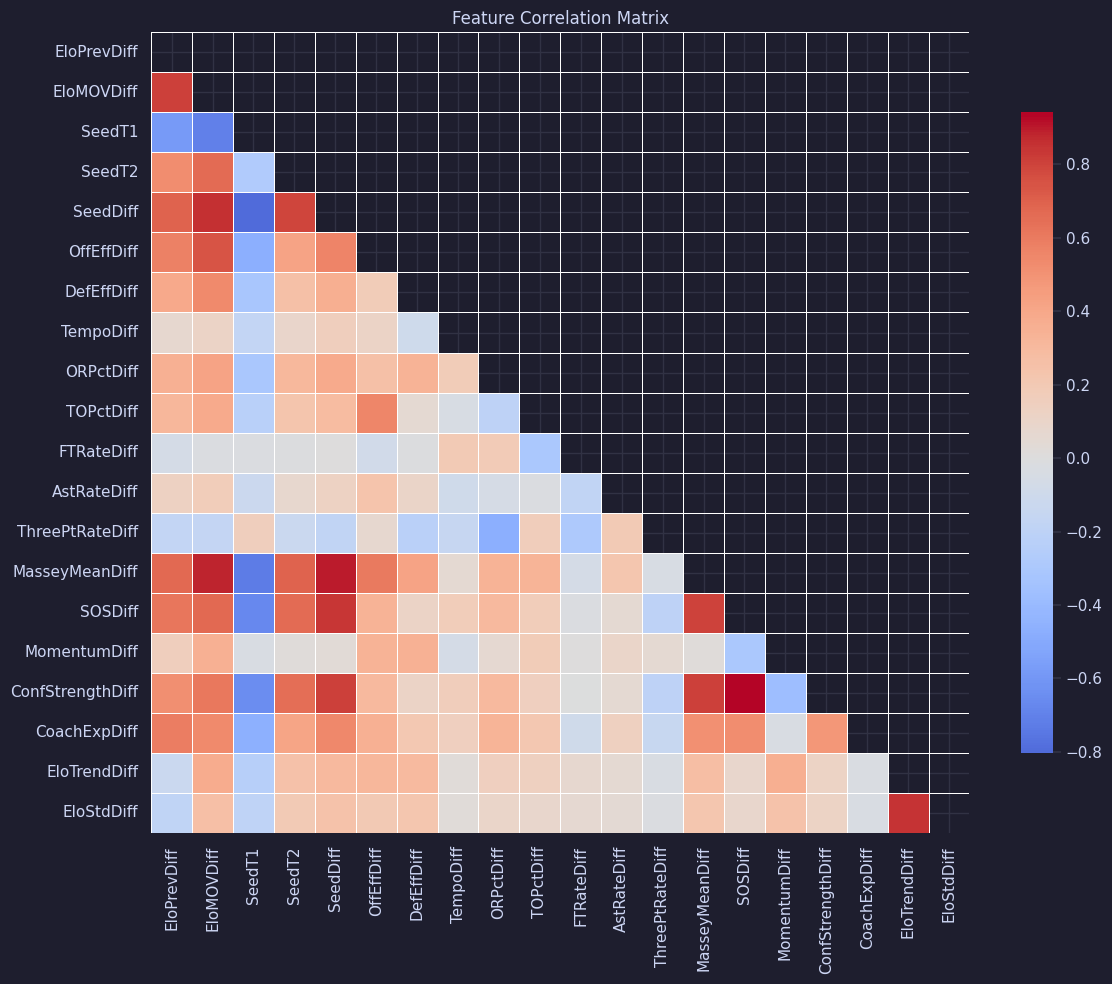

In [22]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Compute training-set medians for NaN imputation
IMPUTE_MEDIANS = X.median().to_dict()

# Per-gender imputation medians
IMPUTE_MEDIANS_M = X[genders.values == "M"].median().to_dict()
IMPUTE_MEDIANS_W = X[genders.values == "W"].median().to_dict()

# Recency weights: decay=0.60 → 2025→1.0, 2024→0.6, 2023→0.36, 2021→0.13
SAMPLE_WEIGHTS = compute_sample_weights(seasons, decay=0.60)

# Explicit anomaly overrides (multiplied on top of decay weight)
_SEASON_OVERRIDES = {
    2021: 0.10,  # COVID bubble -- all games in Indianapolis, no crowds, unreliable signal
}
for _s, _factor in _SEASON_OVERRIDES.items():
    SAMPLE_WEIGHTS[seasons.values == _s] *= _factor

print("Imputation medians ready (combined + per-gender).")
print(f"Sample weight range: [{SAMPLE_WEIGHTS.min():.5f}, {SAMPLE_WEIGHTS.max():.4f}]")

## 5b. Feature Selection (Shadow Method) — Per Gender

Fit LightGBM 20× with different seeds on original + shuffled "shadow" copies of each feature.
Keep only features whose mean gain importance consistently beats the best shadow feature.

**Men's**: full feature set including Massey + CoachExp.
**Women's**: reduced feature set (no Massey, no CoachExp — always NaN for women).

In [ ]:
import json as _json
from pathlib import Path as _Path

_CACHE = _Path("cache")
_X_PATH  = _CACHE / "X.parquet"
_META_PATH = _CACHE / "meta.json"

# Invalidate cache if it doesn't have gender info
_cache_valid = False
if _X_PATH.exists() and _META_PATH.exists():
    _meta = _json.loads(_META_PATH.read_text())
    _cache_valid = "genders" in _meta and "feature_cols_m" in _meta

if _cache_valid:
    X       = pd.read_parquet(_X_PATH)
    y       = pd.Series(_meta["y"],       name="y")
    seasons = pd.Series(_meta["seasons"], name="Season")
    genders = pd.Series(_meta["genders"], name="Gender")
    FEATURE_COLS    = _meta["feature_cols"]
    FEATURE_COLS_M  = _meta["feature_cols_m"]
    FEATURE_COLS_W  = _meta["feature_cols_w"]
    IMPUTE_MEDIANS  = _meta["impute_medians"]
    IMPUTE_MEDIANS_M = _meta["impute_medians_m"]
    IMPUTE_MEDIANS_W = _meta["impute_medians_w"]
    SAMPLE_WEIGHTS  = np.array(_meta["sample_weights"])
    print(f"[cache] Loaded X{X.shape}")
    print(f"  Men's features  ({len(FEATURE_COLS_M)}): {FEATURE_COLS_M}")
    print(f"  Women's features ({len(FEATURE_COLS_W)}): {FEATURE_COLS_W}")

else:
    from lightgbm import LGBMClassifier as _LGBM
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

    def _shadow_select(X_sub, y_sub, force_keep, label):
        """Run shadow feature selection on a subset of data."""
        N_RUNS = 20
        imp_medians = X_sub.median().to_dict()
        X_imp = X_sub.fillna(imp_medians)
        # Drop all-NaN columns
        valid_cols = [c for c in X_imp.columns if X_imp[c].notna().any()]
        X_imp = X_imp[valid_cols]
        orig_cols = list(X_imp.columns)

        importance_orig   = np.zeros(len(orig_cols))
        importance_shadow = np.zeros(len(orig_cols))

        rng = np.random.default_rng(42)
        for run in range(N_RUNS):
            X_shadow = X_imp.copy()
            shadow_cols = [f"shadow_{c}" for c in orig_cols]
            for col, scol in zip(orig_cols, shadow_cols):
                X_shadow[scol] = rng.permutation(X_imp[col].values)

            m = _LGBM(n_estimators=200, max_depth=4, learning_rate=0.05,
                       num_leaves=31, verbose=-1, random_state=run)
            m.fit(X_shadow.values, y_sub.values)

            imp = dict(zip(orig_cols + shadow_cols, m.feature_importances_))
            for i, col in enumerate(orig_cols):
                importance_orig[i]   += imp[col]
                importance_shadow[i] += imp[f"shadow_{col}"]

        importance_orig   /= N_RUNS
        importance_shadow /= N_RUNS

        threshold = importance_shadow.mean()
        selected = [
            col for col, imp in zip(orig_cols, importance_orig)
            if imp > threshold or col in force_keep
        ]
        dropped = [col for col in orig_cols if col not in selected]
        print(f"\n{label} shadow threshold: {threshold:.1f}")
        print(f"  KEPT    ({len(selected)}): {selected}")
        print(f"  DROPPED ({len(dropped)}): {dropped}")
        return selected

    # Men's: include Massey + CoachExp
    m_mask = (genders == "M").values
    FEATURE_COLS_M = _shadow_select(
        X[m_mask], y[m_mask],
        force_keep={"MasseyMeanDiff", "CoachExpDiff", "SeedT1", "SeedT2"},
        label="Men's",
    )

    # Women's: exclude men-only features, simpler set
    w_mask = (genders == "W").values
    w_cols_candidate = [c for c in X.columns if c not in ("MasseyMeanDiff", "CoachExpDiff")]
    FEATURE_COLS_W = _shadow_select(
        X.loc[w_mask, w_cols_candidate], y[w_mask],
        force_keep={"SeedT1", "SeedT2", "SeedDiff"},
        label="Women's",
    )

    # Combined feature cols = union (for the full X matrix)
    FEATURE_COLS = sorted(set(FEATURE_COLS_M) | set(FEATURE_COLS_W))
    IMPUTE_MEDIANS   = X[FEATURE_COLS].median().to_dict()
    IMPUTE_MEDIANS_M = X.loc[m_mask, FEATURE_COLS_M].median().to_dict()
    IMPUTE_MEDIANS_W = X.loc[w_mask, FEATURE_COLS_W].median().to_dict()

    print(f"\nCombined feature union: {len(FEATURE_COLS)} features")

    # Save to cache
    _CACHE.mkdir(exist_ok=True)
    X.to_parquet(_X_PATH)
    _META_PATH.write_text(_json.dumps({
        "y":              y.tolist(),
        "seasons":        seasons.tolist(),
        "genders":        genders.tolist(),
        "feature_cols":   FEATURE_COLS,
        "feature_cols_m": FEATURE_COLS_M,
        "feature_cols_w": FEATURE_COLS_W,
        "impute_medians":   IMPUTE_MEDIANS,
        "impute_medians_m": IMPUTE_MEDIANS_M,
        "impute_medians_w": IMPUTE_MEDIANS_W,
        "sample_weights": SAMPLE_WEIGHTS.tolist(),
    }))
    print("[cache] Saved to cache/")

In [25]:
import gc
# Free shadow selection intermediates
for _v in ['X_imp_full', 'importance_orig', 'importance_shadow']:
    if _v in dir(): del _v
gc.collect()
print('Memory freed after shadow selection')

Memory freed after shadow selection


## 6. Gender-Split Model Training with LOSO CV

**Men's**: XGBoost + LightGBM + CatBoost + TabICL (full features incl. Massey/Coach)
**Women's**: LightGBM + TabICL (simpler features, fewer upsets → simpler models)

Leave-one-season-out (LOSO) trains on all seasons except one, evaluates on the held-out season.

In [ ]:
# ── Men's data split ──
m_mask = (genders == "M").values
X_m = X.loc[m_mask, FEATURE_COLS_M]
y_m = y[m_mask].reset_index(drop=True)
seasons_m = seasons[m_mask].reset_index(drop=True)
weights_m = SAMPLE_WEIGHTS[m_mask]
X_m_imputed = X_m.fillna(IMPUTE_MEDIANS_M)

print(f"Men's training: {X_m.shape[0]:,} games, {X_m.shape[1]} features")
print(f"Features: {FEATURE_COLS_M}")

# Men's XGBoost
xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

xgb_model_m = train_or_load(
    "xgboost_m",
    XGBClassifier,
    X_m.values, y_m.values,
    param_dist=xgb_params,
    random_state=RANDOM_STATE,
    model_kwargs={"eval_metric": "logloss", "verbosity": 0},
    sample_weight=weights_m,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nMen's XGBoost LOSO CV:")
xgb_cv_m, xgb_oof_m = leave_one_season_out_cv(
    lambda: XGBClassifier(**{k: v for k, v in xgb_model_m.get_params().items() if k != "device"}),
    X_m, y_m, seasons_m,
    sample_weight=weights_m,
    return_preds=True,
)

In [ ]:
# Men's LightGBM
lgbm_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_samples": [5, 10, 20],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

lgbm_model_m = train_or_load(
    "lightgbm_m",
    LGBMClassifier,
    X_m.values, y_m.values,
    param_dist=lgbm_params,
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": -1},
    sample_weight=weights_m,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nMen's LightGBM LOSO CV:")
lgbm_cv_m, lgbm_oof_m = leave_one_season_out_cv(
    lambda: LGBMClassifier(**{k: v for k, v in lgbm_model_m.get_params().items() if k != "device"}),
    X_m, y_m, seasons_m,
    sample_weight=weights_m,
    return_preds=True,
)

In [ ]:
# Men's CatBoost
cb_params = {
    "iterations": [500, 1000, 2000],
    "depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.02, 0.05],
    "l2_leaf_reg": [1, 3, 5, 10],
    "min_data_in_leaf": [5, 10, 20],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bylevel": [0.7, 0.8, 0.9],
}

cb_model_m = train_or_load(
    "catboost_m",
    CatBoostClassifier,
    X_m_imputed.values, y_m.values,
    param_dist=cb_params,
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": 0, "eval_metric": "Logloss", "bootstrap_type": "Bernoulli"},
    sample_weight=weights_m,
    n_iter=40, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nMen's CatBoost LOSO CV:")
cb_cv_m, cb_oof_m = leave_one_season_out_cv(
    lambda: CatBoostClassifier(**{k: v for k, v in cb_model_m.get_params().items()
                                  if k not in ("nan_value_treatment", "verbose", "task_type", "bootstrap_type")},
                               verbose=0, bootstrap_type="Bernoulli"),
    X_m, y_m, seasons_m,
    impute=True,
    sample_weight=weights_m,
    return_preds=True,
)

In [ ]:
# Men's TabICL v2
tabicl_model_m = train_or_load("tabicl_m", TabICLClassifier, X_m_imputed.values, y_m.values,
                                param_dist=None, model_kwargs={"n_estimators": 16})

print("\nMen's TabICL LOSO CV:")
tabicl_cv_m, tabicl_oof_m = leave_one_season_out_cv(
    lambda: TabICLClassifier(n_estimators=16, random_state=RANDOM_STATE),
    X_m, y_m, seasons_m,
    impute=True,
    return_preds=True,
)

In [ ]:
# ── Women's data split ──
w_mask = (genders == "W").values
X_w = X.loc[w_mask, FEATURE_COLS_W].reset_index(drop=True)
y_w = y[w_mask].reset_index(drop=True)
seasons_w = seasons[w_mask].reset_index(drop=True)
weights_w = SAMPLE_WEIGHTS[w_mask]
X_w_imputed = X_w.fillna(IMPUTE_MEDIANS_W)

print(f"Women's training: {X_w.shape[0]:,} games, {X_w.shape[1]} features")
print(f"Features: {FEATURE_COLS_W}")

# Women's LightGBM (simpler model for more predictable tournament)
lgbm_model_w = train_or_load(
    "lightgbm_w",
    LGBMClassifier,
    X_w.values, y_w.values,
    param_dist={
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [7, 15, 31],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "min_child_samples": [5, 10, 20],
        "reg_alpha": [0, 0.1, 1.0],
        "reg_lambda": [1.0, 2.0, 5.0],
    },
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": -1},
    sample_weight=weights_w,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nWomen's LightGBM LOSO CV:")
lgbm_cv_w, lgbm_oof_w = leave_one_season_out_cv(
    lambda: LGBMClassifier(**{k: v for k, v in lgbm_model_w.get_params().items() if k != "device"}),
    X_w, y_w, seasons_w,
    sample_weight=weights_w,
    return_preds=True,
)

# Women's TabICL v2
tabicl_model_w = train_or_load("tabicl_w", TabICLClassifier, X_w_imputed.values, y_w.values,
                                param_dist=None, model_kwargs={"n_estimators": 16})

print("\nWomen's TabICL LOSO CV:")
tabicl_cv_w, tabicl_oof_w = leave_one_season_out_cv(
    lambda: TabICLClassifier(n_estimators=16, random_state=RANDOM_STATE),
    X_w, y_w, seasons_w,
    impute=True,
    return_preds=True,
)

In [ ]:
# CV summary: Men's
print("=" * 60)
print("MEN'S CV RESULTS")
print("=" * 60)
cv_results_m = {
    "XGBoost":  xgb_cv_m,
    "LightGBM": lgbm_cv_m,
    "CatBoost": cb_cv_m,
    "TabICL":   tabicl_cv_m,
}
cv_df_m = pd.DataFrame(cv_results_m).sort_index()
cv_df_m.loc['Mean (all)']   = cv_df_m.mean()
recent_m = [s for s in cv_results_m['XGBoost'] if s >= 2022]
cv_df_m.loc['Mean (22-25)'] = cv_df_m.loc[recent_m].mean()
print(cv_df_m.round(4).to_string())

print("\n")
print("=" * 60)
print("WOMEN'S CV RESULTS")
print("=" * 60)
cv_results_w = {
    "LightGBM": lgbm_cv_w,
    "TabICL":   tabicl_cv_w,
}
cv_df_w = pd.DataFrame(cv_results_w).sort_index()
cv_df_w.loc['Mean (all)']   = cv_df_w.mean()
recent_w = [s for s in cv_results_w['LightGBM'] if s >= 2022]
cv_df_w.loc['Mean (22-25)'] = cv_df_w.loc[recent_w].mean()
print(cv_df_w.round(4).to_string())

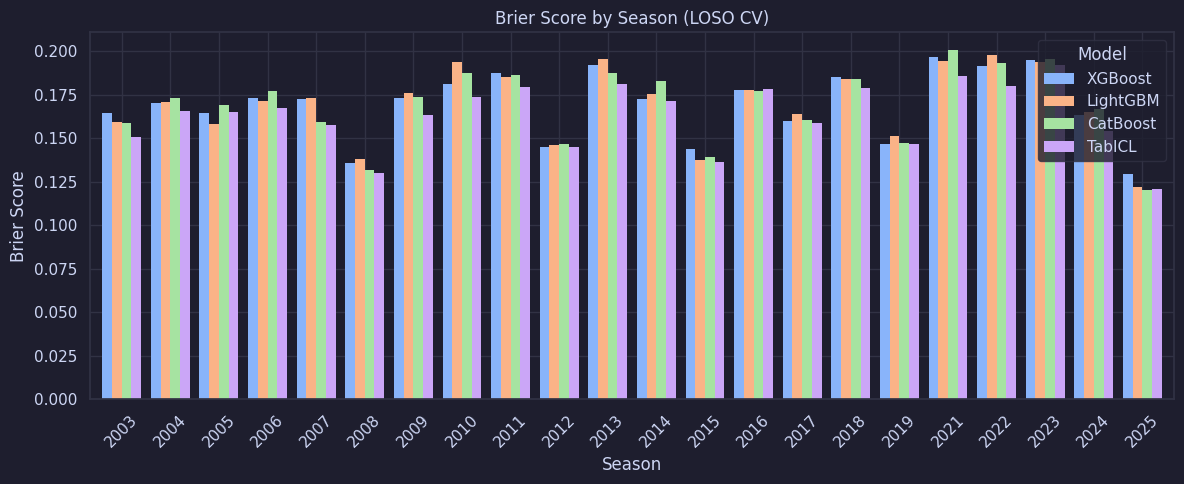

In [32]:
plot_brier_by_season(cv_results, C.cycle)
plt.show()

## 7. Ensemble

In [ ]:
from scipy.optimize import minimize

def optimize_weights(oofs, y_arr, seasons_arr, model_names, label=""):
    """Optimize ensemble weights on recent OOF predictions."""
    recent_mask = np.array([s >= 2022 for s in seasons_arr])
    n = len(model_names)
    def neg_brier(w):
        w = np.abs(w) / np.abs(w).sum()
        preds = oofs[recent_mask] @ w
        return np.mean((preds - y_arr[recent_mask]) ** 2)
    res = minimize(neg_brier, x0=[1.0/n]*n,
                   method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})
    w_opt = np.abs(res.x) / np.abs(res.x).sum()
    weights = dict(zip(model_names, w_opt))
    print(f"{label} ensemble weights (22-25 OOF):")
    for name, w in sorted(weights.items(), key=lambda x: -x[1]):
        print(f"  {name:10s}  weight={w:.3f}")
    return weights

# Men's ensemble
oofs_m = np.column_stack([xgb_oof_m, lgbm_oof_m, cb_oof_m, tabicl_oof_m])
model_names_m = ['XGBoost', 'LightGBM', 'CatBoost', 'TabICL']
ens_weights_m = optimize_weights(oofs_m, y_m.values, seasons_m.values, model_names_m, "Men's")

print()

# Women's ensemble
oofs_w = np.column_stack([lgbm_oof_w, tabicl_oof_w])
model_names_w = ['LightGBM', 'TabICL']
ens_weights_w = optimize_weights(oofs_w, y_w.values, seasons_w.values, model_names_w, "Women's")

In [ ]:
# Per-gender ensemble LOSO evaluation
def compute_ensemble_cv(oofs, weights_dict, model_names, y_arr, seasons_arr):
    w = np.array([weights_dict[n] for n in model_names])
    oof_ens = oofs @ w
    cv = {}
    for season in sorted(pd.Series(seasons_arr).unique()):
        mask = seasons_arr == season
        if mask.sum() > 0:
            cv[season] = brier_score(y_arr[mask], oof_ens[mask])
    return cv, oof_ens

ens_cv_m, oof_ens_m = compute_ensemble_cv(oofs_m, ens_weights_m, model_names_m, y_m.values, seasons_m.values)
ens_cv_w, oof_ens_w = compute_ensemble_cv(oofs_w, ens_weights_w, model_names_w, y_w.values, seasons_w.values)

print("MEN'S Ensemble LOSO:")
for s, b in sorted(ens_cv_m.items()):
    print(f"  {s}: {b:.4f}")
print(f"  Mean (all):   {np.mean(list(ens_cv_m.values())):.4f}")
print(f"  Mean (22-25): {np.mean([v for s, v in ens_cv_m.items() if s >= 2022]):.4f}")

print("\nWOMEN'S Ensemble LOSO:")
for s, b in sorted(ens_cv_w.items()):
    print(f"  {s}: {b:.4f}")
print(f"  Mean (all):   {np.mean(list(ens_cv_w.values())):.4f}")
print(f"  Mean (22-25): {np.mean([v for s, v in ens_cv_w.items() if s >= 2022]):.4f}")

In [ ]:
# Combined pooled Brier (2022-2025) — the metric that matters
oof_combined = np.concatenate([oof_ens_m, oof_ens_w])
y_combined = np.concatenate([y_m.values, y_w.values])
seasons_combined = np.concatenate([seasons_m.values, seasons_w.values])

mask_2225 = seasons_combined >= 2022
pooled_brier = brier_score(y_combined[mask_2225], oof_combined[mask_2225])
n_games = mask_2225.sum()

print(f"COMBINED Pooled Brier (2022-2025): {pooled_brier:.5f}  ({n_games} games)")
print(f"  vs. old combined model:          0.16143")
print(f"  Improvement:                     {0.16143 - pooled_brier:+.5f}")

# Per-gender breakdown
mask_m_2225 = seasons_m.values >= 2022
mask_w_2225 = seasons_w.values >= 2022
print(f"\n  Men's pooled (22-25):   {brier_score(y_m.values[mask_m_2225], oof_ens_m[mask_m_2225]):.5f}  ({mask_m_2225.sum()} games)")
print(f"  Women's pooled (22-25): {brier_score(y_w.values[mask_w_2225], oof_ens_w[mask_w_2225]):.5f}  ({mask_w_2225.sum()} games)")

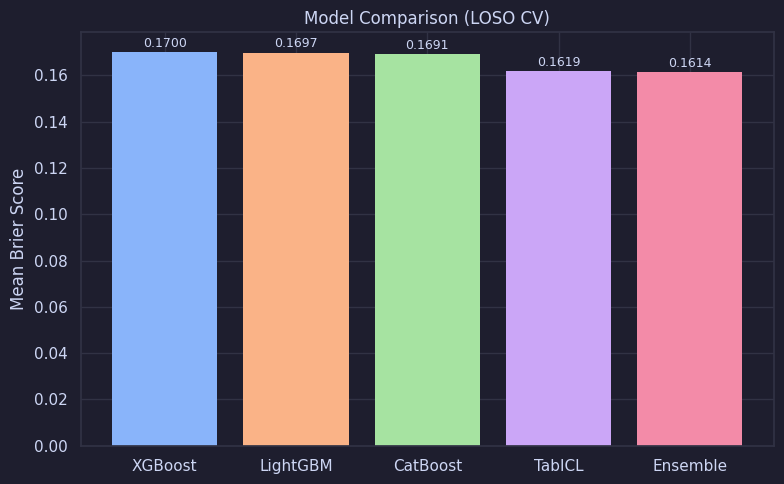

In [36]:
plot_model_comparison(mean_briers, C.cycle)
plt.show()

## 8. Submission Generation

In [ ]:
models_m = {
    "XGBoost":  xgb_model_m,
    "LightGBM": lgbm_model_m,
    "CatBoost": cb_model_m,
    "TabICL":   tabicl_model_m,
}
models_w = {
    "LightGBM": lgbm_model_w,
    "TabICL":   tabicl_model_w,
}

In [ ]:
# Stage 1: seasons 2022–2025
sub1 = generate_submission_gendered(
    data["sample_sub"], models_m, models_w, ens_weights_m, ens_weights_w,
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    feature_cols_m=FEATURE_COLS_M,
    feature_cols_w=FEATURE_COLS_W,
    impute_medians_m=IMPUTE_MEDIANS_M,
    impute_medians_w=IMPUTE_MEDIANS_W,
    elo_stats=elo_stats,
    sos=sos, momentum=momentum,
    conf_strength=conf_strength, coach_exp=coach_exp,
)
sub1.to_csv("submission_stage1.csv", index=False)
print(f"\nStage 1: {sub1.shape[0]:,} rows")
print(f"Range : [{sub1['Pred'].min():.4f}, {sub1['Pred'].max():.4f}]")
print(f"Mean  : {sub1['Pred'].mean():.4f}  Std: {sub1['Pred'].std():.4f}")
sub1.head()

In [ ]:
# Stage 2: season 2026
sub2 = generate_submission_gendered(
    data["sample_sub2"], models_m, models_w, ens_weights_m, ens_weights_w,
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    feature_cols_m=FEATURE_COLS_M,
    feature_cols_w=FEATURE_COLS_W,
    impute_medians_m=IMPUTE_MEDIANS_M,
    impute_medians_w=IMPUTE_MEDIANS_W,
    elo_stats=elo_stats,
    sos=sos, momentum=momentum,
    conf_strength=conf_strength, coach_exp=coach_exp,
)
sub2.to_csv("submission_stage2.csv", index=False)
print(f"\nStage 2: {sub2.shape[0]:,} rows")
print(f"Range : [{sub2['Pred'].min():.4f}, {sub2['Pred'].max():.4f}]")
print(f"Mean  : {sub2['Pred'].mean():.4f}  Std: {sub2['Pred'].std():.4f}")
sub2.head()

## 9. Validation Visualizations

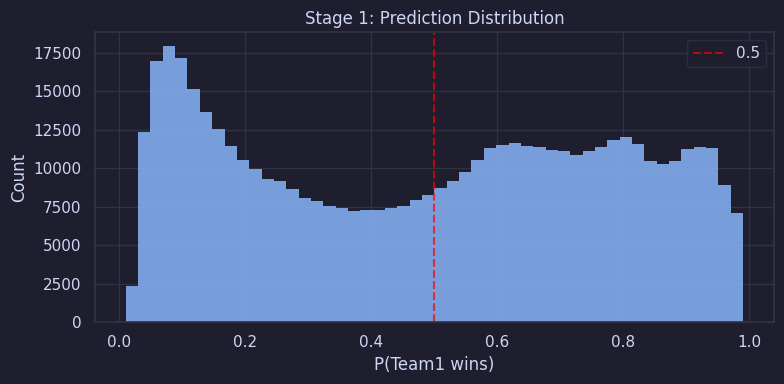

In [40]:
plot_prediction_distribution(sub1["Pred"], color=C.blue)
plt.title("Stage 1: Prediction Distribution")
plt.show()

In [ ]:
# Feature importance: Men's XGBoost and LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_feature_importance(xgb_model_m,  FEATURE_COLS_M, top_n=15, color=C.blue,  ax=axes[0])
plot_feature_importance(lgbm_model_m, FEATURE_COLS_M, top_n=15, color=C.peach, ax=axes[1])
axes[0].set_title("Men's XGBoost Feature Importance")
axes[1].set_title("Men's LightGBM Feature Importance")
plt.tight_layout()
plt.show()

# Women's LightGBM feature importance
fig, ax = plt.subplots(figsize=(8, 5))
plot_feature_importance(lgbm_model_w, FEATURE_COLS_W, top_n=15, color=C.pink, ax=ax)
ax.set_title("Women's LightGBM Feature Importance")
plt.tight_layout()
plt.show()

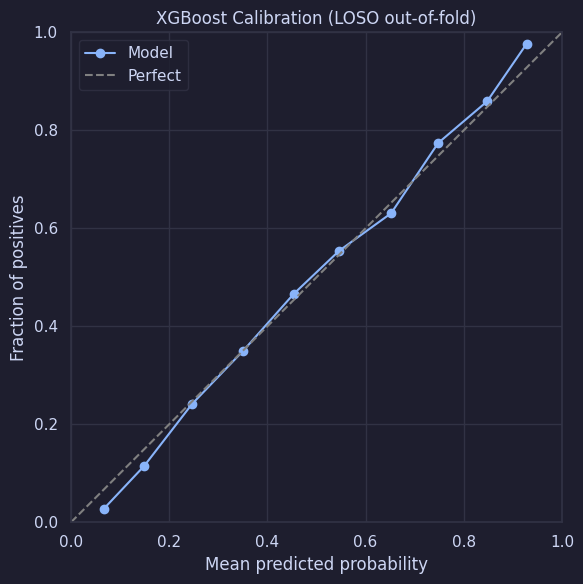

In [42]:
# Calibration curve on LOSO held-out predictions (proper out-of-fold)
oof_preds = np.zeros(len(y))
for season in sorted(seasons.unique()):
    train_mask = seasons != season
    test_mask  = seasons == season
    m = XGBClassifier(**xgb_model.get_params())
    m.fit(X[train_mask].values, y[train_mask].values)
    oof_preds[test_mask] = m.predict_proba(X[test_mask].values)[:, 1]

plot_calibration_curve(y.values, oof_preds, color=C.blue)
plt.title("XGBoost Calibration (LOSO out-of-fold)")
plt.show()

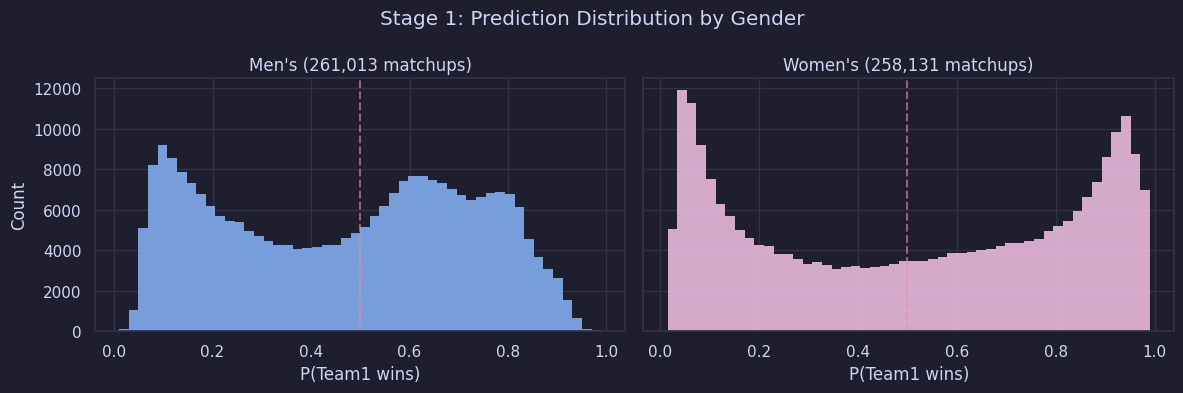

In [43]:
# Men's vs Women's prediction distributions (Stage 1)
ids_parsed = sub1["ID"].str.split("_", expand=True).astype(int)
is_mens = ids_parsed[1] < 2000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (mask, title, color) in zip(axes, [
    (is_mens,  "Men's",   C.blue),
    (~is_mens, "Women's", C.pink),
]):
    preds_sub = sub1.loc[mask.values, "Pred"]
    ax.hist(preds_sub, bins=50, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(0.5, color=C.red, linestyle="--", alpha=0.6)
    ax.set_xlabel("P(Team1 wins)")
    ax.set_title(f"{title} ({len(preds_sub):,} matchups)")
axes[0].set_ylabel("Count")
plt.suptitle("Stage 1: Prediction Distribution by Gender")
plt.tight_layout()
plt.show()

In [44]:
# Sanity check: seed-based predictions for 2024
check_season = 2024
check_sub = sub1[sub1["ID"].str.startswith(f"{check_season}_")].copy()
check_ids = check_sub["ID"].str.split("_", expand=True).astype(int)
check_ids.columns = ["Season", "T1", "T2"]
check_ids["Seed1"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T1"])), axis=1)
check_ids["Seed2"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T2"])), axis=1)
check_ids["Pred"]  = check_sub["Pred"].values

seeded = check_ids.dropna(subset=["Seed1", "Seed2"])
print(f"Seeded matchups in {check_season}: {len(seeded):,}")

vs1_16 = seeded[(seeded["Seed1"] == 1) & (seeded["Seed2"] == 16)]
print(f"\n1 vs 16 seed predictions (expect >0.5 for Team1):")
print(vs1_16[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

vs8_9  = seeded[(seeded["Seed1"] == 8) & (seeded["Seed2"] == 9)]
print(f"\n8 vs 9 seed predictions (expect ~0.5):")
print(vs8_9[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

Seeded matchups in 2024: 4,556

1 vs 16 seed predictions (expect >0.5 for Team1):
  T1   T2  Seed1  Seed2  Pred
1163 1212    1.0   16.0 0.968
1163 1224    1.0   16.0 0.976
1163 1255    1.0   16.0 0.967
1163 1286    1.0   16.0 0.953
1163 1391    1.0   16.0 0.965
1163 1447    1.0   16.0 0.979
1222 1224    1.0   16.0 0.985
1222 1255    1.0   16.0 0.981
1222 1286    1.0   16.0 0.980
1222 1391    1.0   16.0 0.985
1222 1447    1.0   16.0 0.988
1314 1391    1.0   16.0 0.957
1314 1447    1.0   16.0 0.974
1345 1391    1.0   16.0 0.980
1345 1447    1.0   16.0 0.977
3234 3342    1.0   16.0 0.990
3234 3357    1.0   16.0 0.989
3234 3394    1.0   16.0 0.988
3234 3404    1.0   16.0 0.990
3376 3394    1.0   16.0 0.990
3376 3404    1.0   16.0 0.990
3400 3404    1.0   16.0 0.990

8 vs 9 seed predictions (expect ~0.5):
  T1   T2  Seed1  Seed2  Pred
1194 1277    8.0    9.0 0.519
1194 1321    8.0    9.0 0.551
1194 1395    8.0    9.0 0.536
1194 1401    8.0    9.0 0.503
1280 1321    8.0    9.0 0.603
1280 139

In [45]:
# stage_1 = pd.read_csv("../working/submission_stage1.csv")
stage_2 = pd.read_csv("../working/submission_stage2.csv")
stage_2.to_csv("submission.csv", index=False)
print(f"Wrote {len(stage_2)} rows to submission.csv")

Wrote 132133 rows to submission.csv
